In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set(style="whitegrid")

# Load CFPB complaints dataset
data_path = "../data/raw/complaints.csv"  
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
df.head()


C:\Users\Admin\AppData\Local\Temp\ipykernel_39192\1222988132.py:11: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(data_path)


Dataset shape: (9609797, 18)


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9609797 entries, 0 to 9609796
Data columns (total 18 columns):
 #   Column                        Dtype 
---  ------                        ----- 
 0   Date received                 object
 1   Product                       object
 2   Sub-product                   object
 3   Issue                         object
 4   Sub-issue                     object
 5   Consumer complaint narrative  object
 6   Company public response       object
 7   Company                       object
 8   State                         object
 9   ZIP code                      object
 10  Tags                          object
 11  Consumer consent provided?    object
 12  Submitted via                 object
 13  Date sent to company          object
 14  Company response to consumer  object
 15  Timely response?              object
 16  Consumer disputed?            object
 17  Complaint ID                  int64 
dtypes: int64(1), object(17)
memory usage: 1.3+

In [4]:
# Count missing narratives
df["Consumer complaint narrative"].isna().sum()

# Distribution of products
df["Product"].value_counts().head(15)


Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

In [5]:
# Complaints with vs without narratives
total = len(df)
with_text = df["Consumer complaint narrative"].notna().sum()
without_text = total - with_text

print(f"Total complaints: {total}")
print(f"With narrative: {with_text}")
print(f"Without narrative: {without_text}")


Total complaints: 9609797
With narrative: 2980756
Without narrative: 6629041


In [6]:
# Word count per complaint
df["narrative_word_count"] = (
    df["Consumer complaint narrative"]
    .fillna("")
    .apply(lambda x: len(x.split()))
)

df["narrative_word_count"].describe()


count    9.609797e+06
mean     5.446667e+01
std      1.497672e+02
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      5.000000e+01
max      6.469000e+03
Name: narrative_word_count, dtype: float64

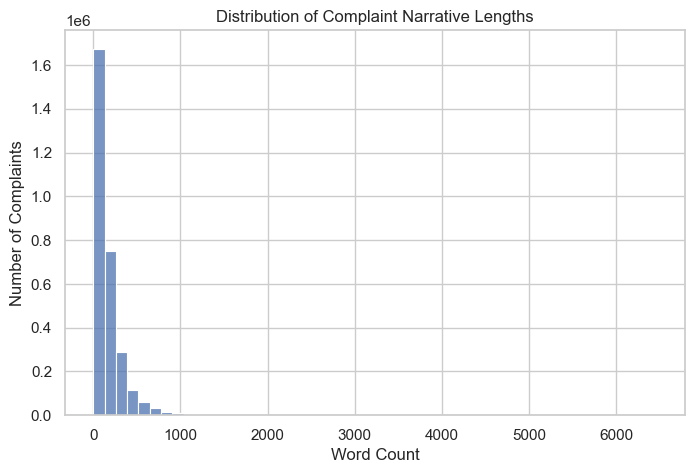

In [7]:
plt.figure(figsize=(8, 5))
sns.histplot(
    df[df["narrative_word_count"] > 0]["narrative_word_count"],
    bins=50
)
plt.title("Distribution of Complaint Narrative Lengths")
plt.xlabel("Word Count")
plt.ylabel("Number of Complaints")
plt.show()


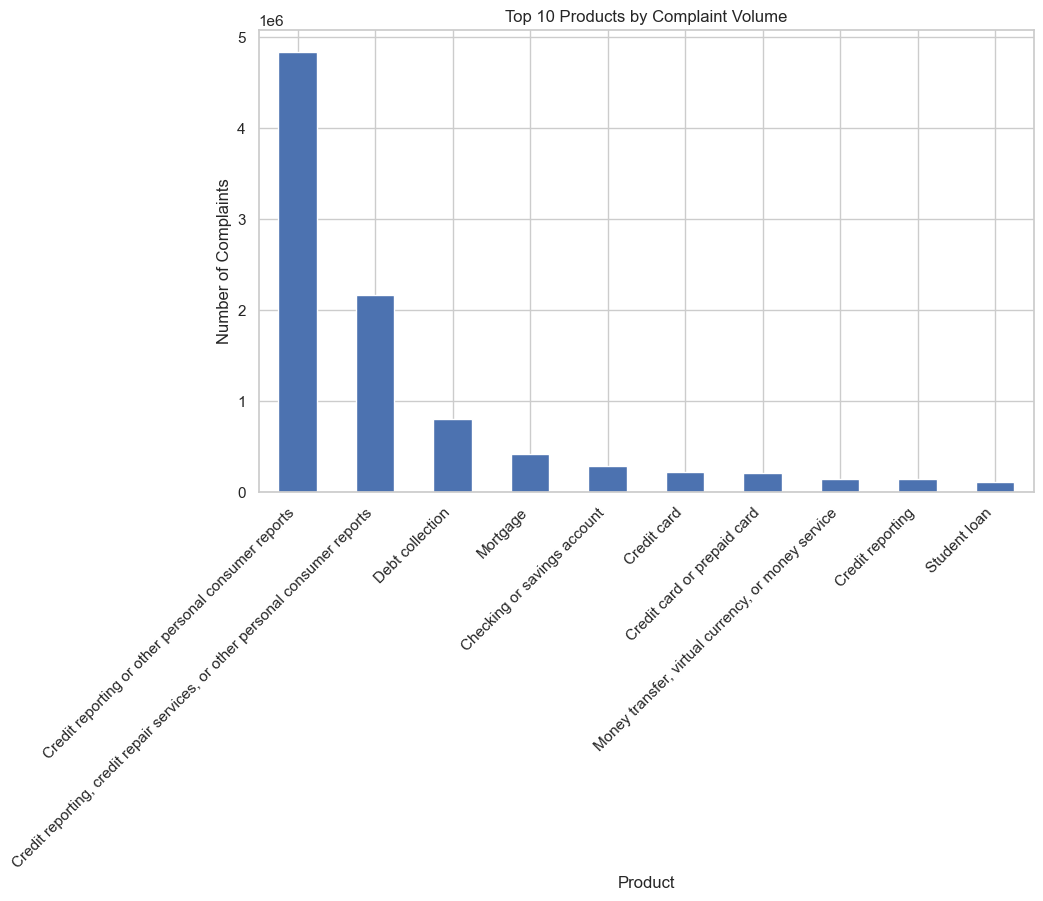

In [8]:
plt.figure(figsize=(10, 6))
df["Product"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Products by Complaint Volume")
plt.xlabel("Product")
plt.ylabel("Number of Complaints")
plt.xticks(rotation=45, ha="right")
plt.show()


In [9]:
TARGET_PRODUCTS = {
    "Credit card": [
        "Credit card",
        "Credit card or prepaid card"
    ],
    "Personal loan": [
        "Payday loan, title loan, or personal loan",
        "Payday loan, title loan, personal loan, or advance loan",
        "Consumer Loan",
        "Vehicle loan or lease",
        "Student loan"
    ],
    "Savings account": [
        "Checking or savings account",
        "Bank account or service"
    ],
    "Money transfer": [
        "Money transfer, virtual currency, or money service"
    ]
}


In [10]:
# Flatten product list
allowed_products = [
    p for products in TARGET_PRODUCTS.values() for p in products
]

df_filtered = df[df["Product"].isin(allowed_products)].copy()

print("Filtered dataset shape:", df_filtered.shape)
df_filtered["Product"].value_counts()


Filtered dataset shape: (1216907, 19)


Product
Checking or savings account                                291178
Credit card                                                226686
Credit card or prepaid card                                206369
Money transfer, virtual currency, or money service         145066
Student loan                                               109717
Bank account or service                                     86205
Vehicle loan or lease                                       72957
Consumer Loan                                               31574
Payday loan, title loan, or personal loan                   30641
Payday loan, title loan, personal loan, or advance loan     16514
Name: count, dtype: int64

In [11]:
df_filtered = df_filtered[
    df_filtered["Consumer complaint narrative"].notna()
].copy()

print("After removing empty narratives:", df_filtered.shape)


After removing empty narratives: (570107, 19)


In [12]:
def normalize_product(product):
    for normalized, variants in TARGET_PRODUCTS.items():
        if product in variants:
            return normalized
    return "Other"

df_filtered["product_category"] = df_filtered["Product"].apply(normalize_product)

df_filtered["product_category"].value_counts()


product_category
Credit card        189334
Savings account    155204
Personal loan      128381
Money transfer      97188
Name: count, dtype: int64

In [13]:
import re

def clean_text(text):
    text = text.lower()
    
    # Remove boilerplate phrases
    boilerplate_patterns = [
        r"i am writing to file a complaint",
        r"this is a complaint",
        r"to whom it may concern"
    ]
    
    for pattern in boilerplate_patterns:
        text = re.sub(pattern, "", text)
    
    # Remove special characters (keep letters & numbers)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    
    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    return text


In [14]:
df_filtered["clean_narrative"] = df_filtered[
    "Consumer complaint narrative"
].apply(clean_text)

df_filtered[["Consumer complaint narrative", "clean_narrative"]].head()


,Consumer complaint narrative,clean_narrative
12237,A XXXX XXXX card was opened under my name by a...,a xxxx xxxx card was opened under my name by a...
12532,I made the mistake of using my wellsfargo debi...,i made the mistake of using my wellsfargo debi...
13280,"Dear CFPB, I have a secured credit card with c...",dear cfpb i have a secured credit card with ci...
13506,I have a Citi rewards cards. The credit balanc...,i have a citi rewards cards the credit balance...
13622,Was never notified of repossession. Once repos...,was never notified of repossession once reposs...


In [ ]:
output_path = "../data/processed/filtered_complaints.csv"
df_filtered.to_csv(output_path, index=False)

print(f"Saved cleaned dataset to {output_path}")
